# HW4

## Logistic Regression

In [113]:
from NumberGenerator import *
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [114]:
n = 50
mx1 = my1 = 1
mx2 = my2 = 3
vx1 = vy1 = 2
vx2 = vy2 = 4
N = 2 * n

In [115]:
def PrintResult(w, d1, d2, ax, title):
    print("\nw:")
    print(w[0])
    print(w[1])
    print(w[2])

    tp = 0
    fn = 0
    fp = 0
    tn = 0
    p1_x = []
    p1_y = []
    p2_x = []
    p2_y = []

    for data in d1:
        z = w[0] + w[1] * data[0] + w[2] * data[1]
        if 1 / (1 + np.exp(-z)) < 0.5:
            tp += 1
            p1_x.append(data[0])
            p1_y.append(data[1])
        else:
            fn += 1
            p2_x.append(data[0])
            p2_y.append(data[1])

    for data in d2:
        z = w[0] + w[1] * data[0] + w[2] * data[1]
        if 1 / (1 + np.exp(-z)) < 0.5:
            fp += 1
            p1_x.append(data[0])
            p1_y.append(data[1])
        else:
            tn += 1
            p2_x.append(data[0])
            p2_y.append(data[1])
    
    print("\nConfusion Matrix:\n")
    print("                      Predict cluster 1       Predict cluster 2")
    print(f"Is cluster 1                 {tp:02d}                      {fn:02d}         ")
    print(f"Is cluster 2                 {fp:02d}                      {tn:02d}         ")
    print()
    print(f"Sensitivity (Successfully predict cluster 1): {tp / (tp + fn)}")
    print(f"Specificity (Successfully predict cluster 2): {tn / (tn + fp)}")
    print("===================================================================================")

    ax.scatter(p1_x, p1_y, color='red')
    ax.scatter(p2_x, p2_y, color='blue')
    ax.set_title(title)

In [116]:
def GradientDescent(phi, y):
    w_old = np.ones((3, 1))
    w_new = np.ones((3, 1))
    learning_rate = 0.1
    threshold = 1e-5
    count = 0

    while count < 10000:
        count += 1
        z = phi.T.dot(w_old)
        y_est = 1 / (1 + np.exp(-z))
        gradient = (1 / N) * phi.dot(y_est - y)
        w_new = w_old - learning_rate * gradient
        
        if np.linalg.norm(w_new - w_old) < threshold:
            break
        w_old = w_new

    return w_new

In [117]:
def NewtonsMethod(phi, y):
    w_old = np.ones((3, 1))
    w_new = np.ones((3, 1))
    learning_rate = 0.1
    threshold = 1e-5
    ones = np.ones((N, 1))
    count = 0

    while count < 10000:
        count += 1
        z = phi.T.dot(w_old)
        y_est = 1 / (1 + np.exp(-z))
        gradient = (1 / N) * phi.dot(y_est - y)
        hessian = (1 / N) * y_est.T.dot(ones - y_est) * phi.dot(phi.T)
        
        if np.linalg.det(hessian) == 0:
            w_new = w_old - learning_rate * gradient
        else:
            w_new = w_old - np.linalg.inv(hessian).dot(gradient)

        if np.linalg.norm(w_new - w_old) < threshold:
            break
        
        w_old = w_new

    return w_new

Gradient descent:

w:
[-2.36531125]
[0.6298832]
[0.56150661]

Confusion Matrix:

                      Predict cluster 1       Predict cluster 2
Is cluster 1                 41                      09         
Is cluster 2                 12                      38         

Sensitivity (Successfully predict cluster 1): 0.82
Specificity (Successfully predict cluster 2): 0.76
Newton`s method:

w:
[-2.37044669]
[0.63098587]
[0.56285083]

Confusion Matrix:

                      Predict cluster 1       Predict cluster 2
Is cluster 1                 41                      09         
Is cluster 2                 12                      38         

Sensitivity (Successfully predict cluster 1): 0.82
Specificity (Successfully predict cluster 2): 0.76


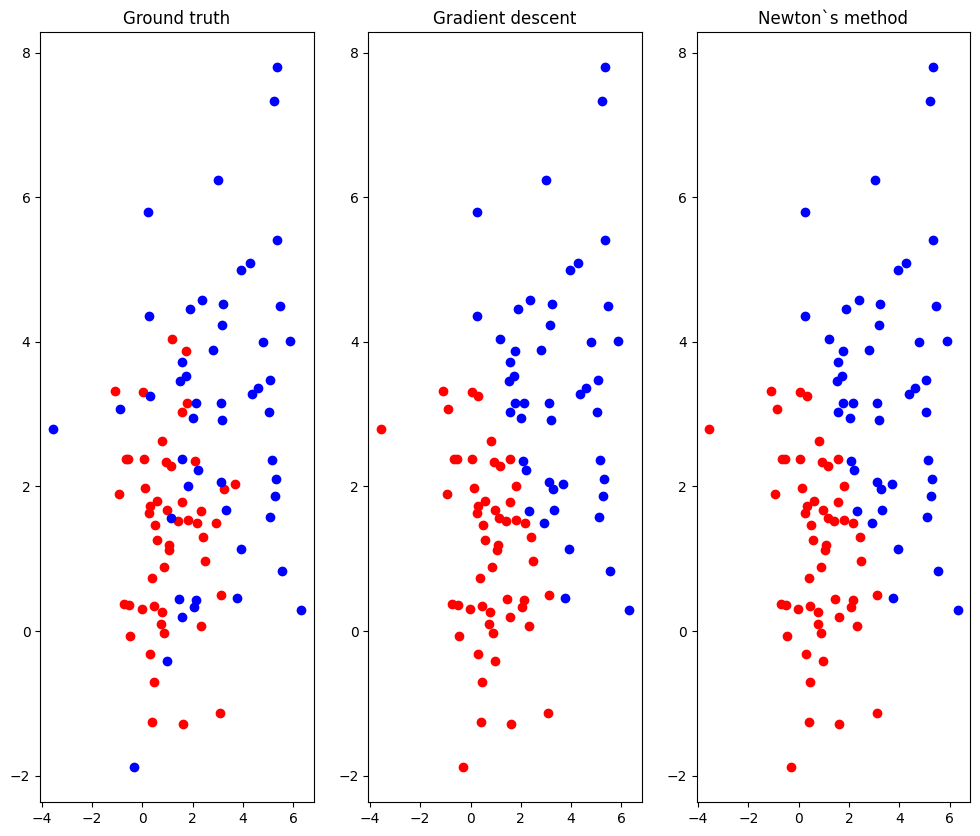

In [118]:
d1 = []
d2 = []

for i in range(n):
    d1.append([Normal(mx1, vx1), Normal(my1, vy1)])
    d2.append([Normal(mx2, vx2), Normal(my2, vy2)])

d1 = np.array(d1)
d2 = np.array(d2)
D = np.vstack((d1, d2))
phi = np.vstack((np.ones((1, N)), D.T))
y = np.vstack((np.zeros((n, 1)), np.ones((n, 1)))) # labels, 0 for D1 & 1 for D2

fig, axs = plt.subplots(1, 3, figsize=(12, 10))
axs[0].scatter(d1.T[0], d1.T[1], color='red')
axs[0].scatter(d2.T[0], d2.T[1], color='blue')
axs[0].set_title("Ground truth")

w1 = GradientDescent(phi, y)
print("Gradient descent:")
PrintResult(w1, d1, d2, axs[1], "Gradient descent")

w2 = NewtonsMethod(phi, y)
print("Newton`s method:")
PrintResult(w2, d1, d2, axs[2], "Newton`s method")

plt.show()

## EM Algorithm

In [119]:
import numpy as np
import struct
from scipy.special import logsumexp
from tqdm import tqdm, trange
from collections import Counter

In [120]:
train_images_filepath = "train-images.idx3-ubyte_"
train_labels_filepath = "train-labels.idx1-ubyte_"

In [121]:
def LoadImages(filepath):
    with open(filepath,'rb') as f:
        magic, size = struct.unpack(">II", f.read(8))
        nrows, ncols = struct.unpack(">II", f.read(8))
        data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
        data = data.reshape((size, nrows, ncols))

    return data, size, nrows, ncols

def LoadLabels(filepath):
    with open(filepath,'rb') as f:
        magic, size = struct.unpack(">II", f.read(8))
        data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
        # data = data.reshape((size,))

    return data

images, N, n_row, n_col = LoadImages(train_images_filepath)
labels = LoadLabels(train_labels_filepath)

X = images.reshape(N, -1)
X = X // 128
n_pixel = n_row * n_col
n_class = 10

In [122]:
def PrintImages(p, finished, cluster_to_label=[]):
    for k in range(n_class):
        cluster_num = k
        if finished:
            cluster_num = cluster_to_label.index(k)
            print(f"labeled class {k}:")
        else:
            print(f"class {k}:")

        for i in range(n_pixel):
            if p[i, cluster_num] > 0.5:
                print("1 ", end='')
            else:
                print("0 ", end='')
            
            if (i + 1) % n_col == 0:
                print()

        print()

In [128]:
def PrintScores(y_true, y_pred):
    cm = np.zeros((n_class, n_class), dtype=int)

    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    for k in range(n_class):
        tp = cm[k, k]
        fn = sum(cm[k, :]) - tp
        fp = sum(cm[:, k]) - tp
        tn = N - tp - fn - fp

        print(f"\nConfusion Matrix {k}:\n")
        print(f"                      Predict number {k}       Predict not number {k}")
        print(f"Is number {k}                 {tp:05d}                  {fn:05d}")
        print(f"Isn`t number {k}              {fp:05d}                  {tn:05d}")
        print()
        print(f"Sensitivity (Successfully predict number {k}):     {tp / (tp + fn)}")
        print(f"Specificity (Successfully predict not number {k}): {tn / (tn + fp)}")
        print("\n--------------------------------------------------------------------\n")


In [129]:
lambda_old = np.array([0.2 for i in range(n_class)])
lambda_new = np.array([0.2 for i in range(n_class)])
p_old = np.random.rand(n_pixel, n_class) * 0.4 + 0.2
p_new = np.ones((n_pixel, n_class))
w = np.zeros((N, n_class))
threshold = 1e-2
iteration = 0
prev_sum_log_likelihood = -np.inf

while iteration < 100:
    iteration += 1
    # E Step
    log_p = np.log(p_old + 1e-10)
    log_q = np.log(1 - p_old + 1e-10)
    log_likelihood = X @ log_p + (1 - X) @ log_q + np.log(lambda_old + 1e-10)
    log_w = log_likelihood - logsumexp(log_likelihood, axis=1, keepdims=True)
    w = np.exp(log_w)

    sum_log_likelihood = np.sum(log_likelihood)
    difference = abs(sum_log_likelihood - prev_sum_log_likelihood) / N # 判斷收斂

    # M Step
    lambda_new = np.mean(w, axis=0)
    p_new = (X.T @ w) / np.sum(w, axis=0, keepdims=True)

    PrintImages(p_new, False)
    print(f"No. of Iteration: {iteration}, Difference: {difference}")
    print("\n--------------------------------------------------------------------\n")

    if difference < threshold:
        break

    lambda_old = np.copy(lambda_new)
    p_old = np.copy(p_new)
    prev_sum_log_likelihood = sum_log_likelihood

class 0:
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 

In [130]:
cluster_pred = np.argmax(w, axis=1)
cluster_to_label = [] # 對照表

for k in range(n_class):
    true_labels_in_k = labels[cluster_pred == k] # cluster k 的真實 label 都是哪些數字
    label_counts = Counter(true_labels_in_k)
    
    # 找出裡面最多的那個數字 label，但被用過的不能再用
    for label, count in label_counts.most_common():
        if label not in cluster_to_label:
            cluster_to_label.append(label)
            
            break

predictions = cluster_pred
error = 0
for i in range(N):
    predictions[i] = cluster_to_label[predictions[i]]
    if predictions[i] != labels[i]:
        error += 1

PrintImages(p_new, True, cluster_to_label)
print("\n--------------------------------------------------------------------\n")
PrintScores(labels, predictions)
print(f"Total iteration to converge: {iteration}")
print(f"Total error rate: {error / N}")


labeled class 0:
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 
0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 
0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 
0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 
0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 
0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 
0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 
0 0 0 0 0 0 1 